In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# ==========================================
# 1. Data Fetching
# ==========================================

tickers = [
    'RELIANCE.NS',      # Energy / Conglomerate
    'TCS.NS',           # IT Services
    'HDFCBANK.NS',      # Private Banking
    'INFY.NS',          # IT Services
    'ICICIBANK.NS',     # Private Banking
    'HINDUNILVR.NS',    # FMCG
    'SBIN.NS',          # Public Banking
    'BHARTIARTL.NS',    # Telecom
    'KOTAKBANK.NS',     # Private Banking
    'LT.NS',            # Infrastructure / Engineering
    'SUNPHARMA.NS',     # Pharmaceuticals
    'WIPRO.NS',         # IT Services
    'ASIANPAINT.NS',    # Paints / Consumer
    'MARUTI.NS',        # Automobiles
    'AXISBANK.NS',      # Private Banking
    'BAJFINANCE.NS',    # NBFC / Fintech
    'TITAN.NS',         # Consumer Goods / Jewellery
    'ULTRACEMCO.NS',    # Cement
    'NESTLEIND.NS',     # FMCG
    'POWERGRID.NS',     # Utilities / Power
]

print("Fetching ~1500 days of historical data...")
data = yf.download(tickers, start='2018-01-01', end='2025-05-01')['Close']
returns = data.pct_change().dropna()
n_assets = len(tickers)

Fetching ~1500 days of historical data...


[*********************100%***********************]  20 of 20 completed


In [ ]:
# ==========================================
# 2. Marginal Transformation (PIT)
# ==========================================
# Convert historical returns to pseudo-uniform variables using Empirical CDF
pseudo_uniforms = returns.rank(method='average') / (len(returns) + 1)

In [ ]:
# ==========================================
# 3. Copula Fitting (Gaussian Copula Dependency)
# ==========================================
# Transform uniforms to standard normal to extract the pure dependency matrix
norm_inv = st.norm.ppf(pseudo_uniforms)
corr_matrix = np.corrcoef(norm_inv, rowvar=False)

In [ ]:
# ==========================================
# 4. Monte Carlo Scenario Generation
# ==========================================
n_simulations = 10000

# Generate correlated standard normal variables
mv_normal_samples = st.multivariate_normal(mean=np.zeros(n_assets), cov=corr_matrix).rvs(n_simulations, random_state=42)

# Transform back to the hypercube (Uniforms) -> This completes the Copula step
synthetic_uniforms = st.norm.cdf(mv_normal_samples)

In [ ]:
# ==========================================
# 5. Inverse Transformation (Recovering Fat-Tailed Returns)
# ==========================================
synthetic_returns = np.zeros_like(synthetic_uniforms)

for i, ticker in enumerate(tickers):
    # Fit heavy-tailed Student-t to historical marginals
    params = st.t.fit(returns[ticker])
    # Apply Inverse CDF (PPF) of the fitted t-distribution
    synthetic_returns[:, i] = st.t.ppf(synthetic_uniforms[:, i], *params)

synthetic_returns_df = pd.DataFrame(synthetic_returns, columns=tickers)

In [ ]:
# ==========================================
# 6. Portfolio Risk Computation (VaR & CVaR)
# ==========================================
# Equal-weighted portfolio
weights = np.ones(n_assets) / n_assets
portfolio_sim_returns = synthetic_returns_df.dot(weights)

alpha = 0.05
VaR_95 = np.percentile(portfolio_sim_returns, alpha * 100)
CVaR_95 = portfolio_sim_returns[portfolio_sim_returns <= VaR_95].mean()

print(f"\n--- Portfolio Risk Metrics ---")
print(f"95% Value-at-Risk (VaR):  {VaR_95:.4%}")
print(f"95% Conditional VaR (CVaR): {CVaR_95:.4%}")


--- Portfolio Risk Metrics ---
95% Value-at-Risk (VaR):  -1.5597%
95% Conditional VaR (CVaR): -2.1773%


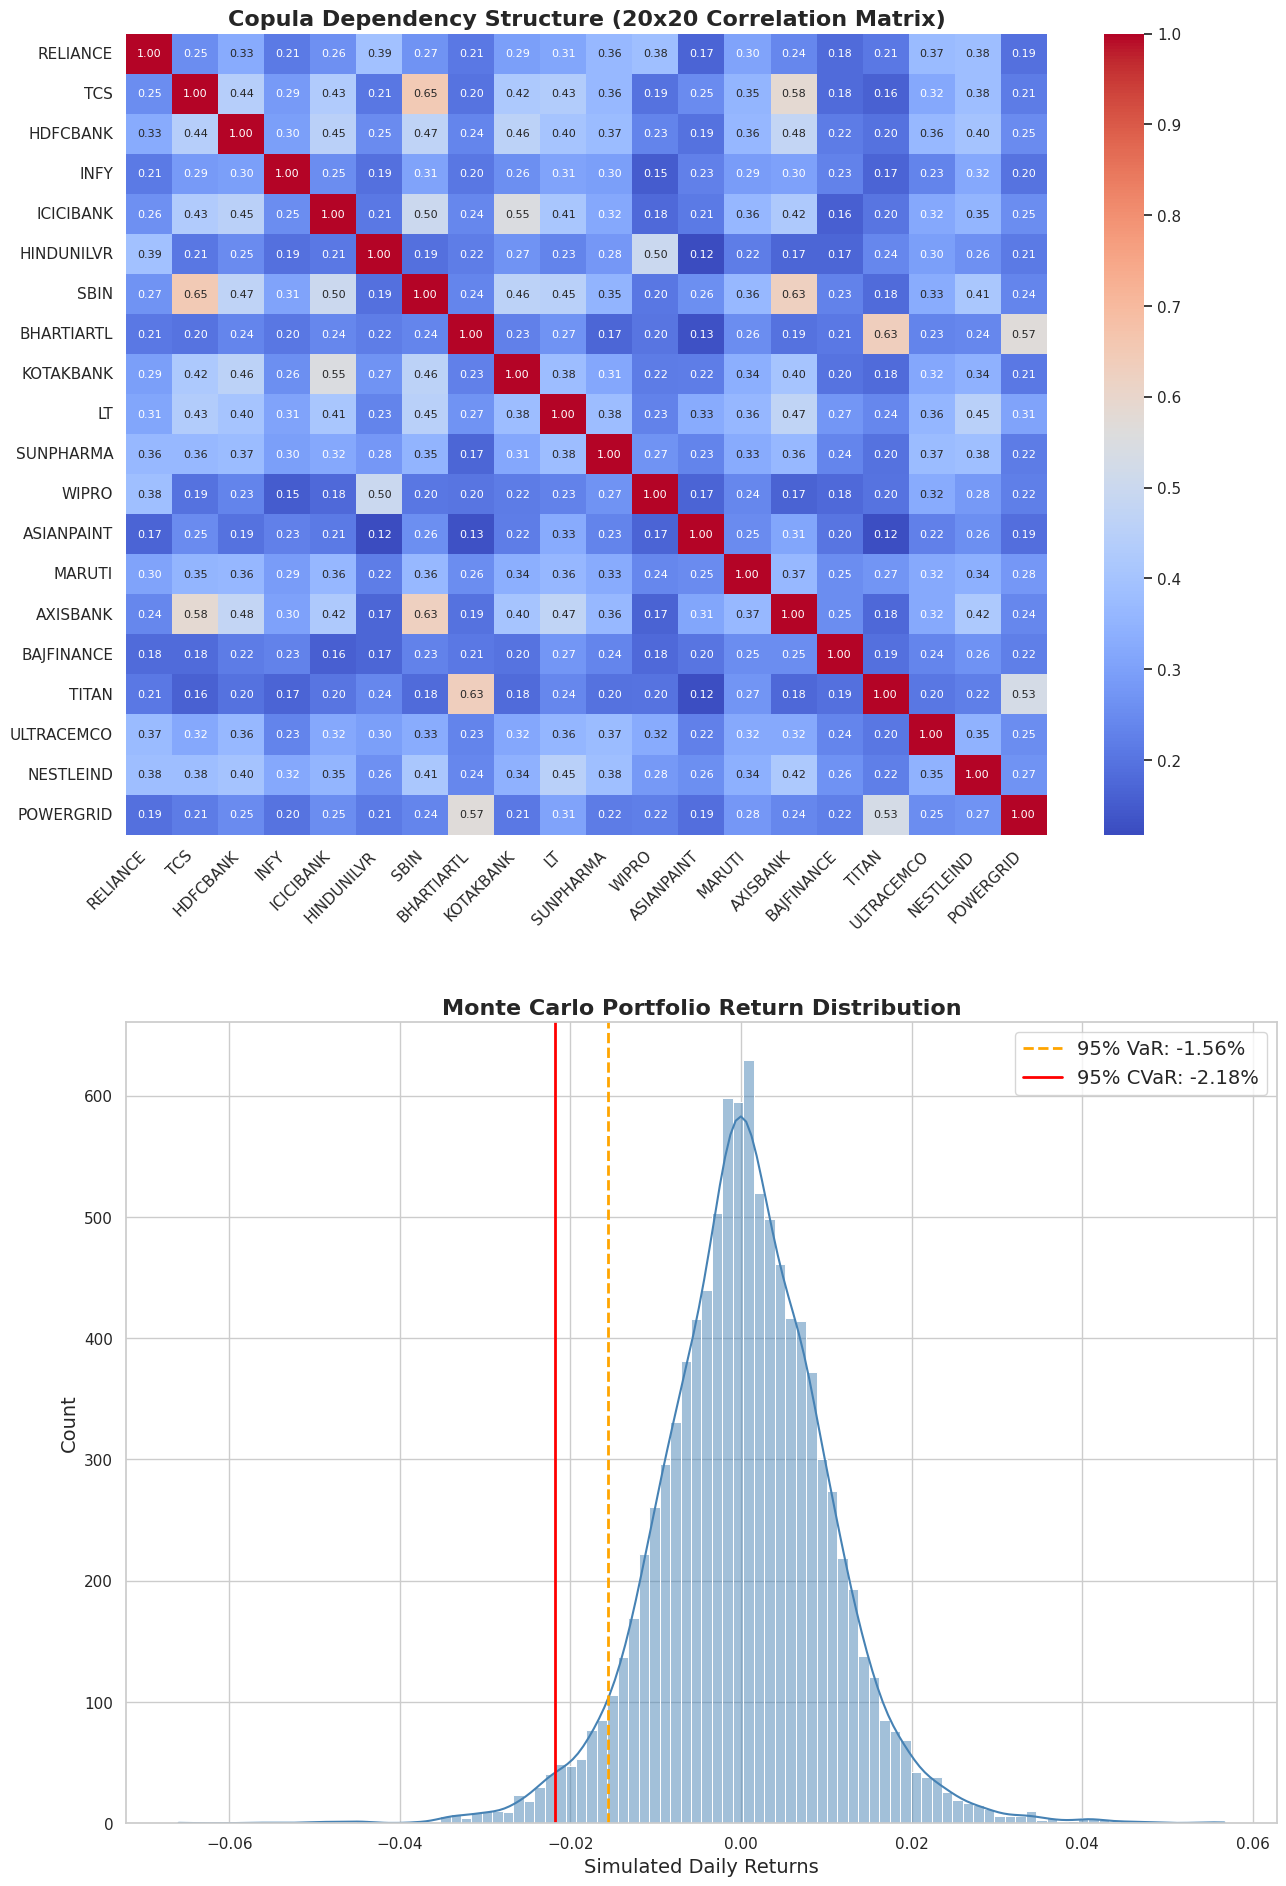

In [ ]:
# ==========================================
# 7. Visualizations (Stacked Vertically)
# ==========================================
sns.set_theme(style="whitegrid")


fig, axes = plt.subplots(2, 1, figsize=(14, 20))

# Graph 1: Copula Dependency Heatmap (Top)
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f",
            annot_kws={"size": 8},
            xticklabels=[t.split('.')[0] for t in tickers],
            yticklabels=[t.split('.')[0] for t in tickers], ax=axes[0])

axes[0].set_title("Copula Dependency Structure (20x20 Correlation Matrix)", fontweight='bold', fontsize=16)

# Keep the rotated labels so the 20 tickers are readable
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

# Graph 2: Simulated Portfolio Returns with Tail Cutoffs (Bottom)
sns.histplot(portfolio_sim_returns, bins=100, kde=True, color='steelblue', ax=axes[1])
axes[1].axvline(VaR_95, color='orange', linestyle='--', linewidth=2, label=f'95% VaR: {VaR_95:.2%}')
axes[1].axvline(CVaR_95, color='red', linestyle='-', linewidth=2, label=f'95% CVaR: {CVaR_95:.2%}')
axes[1].set_title("Monte Carlo Portfolio Return Distribution", fontweight='bold', fontsize=16)
axes[1].set_xlabel("Simulated Daily Returns", fontsize=14)
axes[1].set_ylabel("Count", fontsize=14)
axes[1].legend(fontsize=14)

plt.tight_layout(pad=4.0)
plt.show()